# Step 2a — Baseline Hierarchical Bayesian Accrual Model

In [1]:
import os, pickle, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.pyplot as plt

from hb_shared_utils import (
    load_and_merge, compute_wca, build_regressors, winsorize_by_year,
    assign_indices, mark_usable, build_estimation_window,
    summarize_convergence, extract_sigma_posteriors, build_sigma_summary,
    WINSOR_COLS
)

warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(42)

MODEL_NAME = "baseline"
HB_OUTPUT_DIR = Path("..") / "data" / "hb_results" / MODEL_NAME
HB_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLOT_DIR = HB_OUTPUT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

print(f"PyMC {pm.__version__} | ArviZ {az.__version__} | Model: {MODEL_NAME}")

PyMC 5.28.1 | ArviZ 0.23.4 | Model: baseline


In [2]:
BASE_DIR = Path(".").resolve()
ACC_DIR  = BASE_DIR.parent.parent / "data" / "acc_components_extracted"
PROF_DIR = BASE_DIR.parent.parent / "data" / "prof_components_extracted"

data = load_and_merge(ACC_DIR, PROF_DIR)
data = compute_wca(data)
data = build_regressors(data, include_lead=False)        # baseline: no lead
data, winsor_diag = winsorize_by_year(data, WINSOR_COLS)
data = mark_usable(data)
data, firm_map, sector_map, firm_sector = assign_indices(data)

print(f"Panel: {len(data)} firm-years, {data['Ticker'].nunique()} firms, "
      f"{data['Year'].min()}–{data['Year'].max()}")
print(f"Usable: {data['usable'].sum()}")

[compute_wca] Dropped 24 leading rows with missing CFO across 634 firms
[compute_wca] PPEGT: interpolated 36 interior gaps across 31 firms; skipped 0 gaps with >500% neighbour change (likely structural breaks)
Panel: 9746 firm-years, 634 firms, 2005–2024
Usable: 8891


In [3]:
def build_hb_accrual_model_baseline(window_df, firm_sector_map):
    """
    Baseline HB model: firm intercepts + firm-specific sigma_i.
    NO CFO_{t+1} term. Fit on training rows ONLY.
    """
    import pytensor.tensor as pt
    wdf = window_df.copy()

    # --- Remap firm/sector indices to be contiguous within this window ---
    window_firms = sorted(wdf["firm_idx"].unique())
    window_firm_remap = {old: new for new, old in enumerate(window_firms)}
    wdf["w_firm"] = wdf["firm_idx"].map(window_firm_remap)

    window_firm_to_sector = np.array([
        firm_sector_map[old] for old in window_firms
    ])
    window_sectors = sorted(set(window_firm_to_sector))
    sector_remap = {old: new for new, old in enumerate(window_sectors)}
    window_firm_to_sector = np.array(
        [sector_remap[s] for s in window_firm_to_sector], dtype=int
    )

    # --- Extract arrays ---
    y        = wdf["WCA_scaled"].values
    firm_idx = wdf["w_firm"].values.astype(int)
    cfo_lag1 = wdf["CFO_lag1_scaled"].values
    cfo_curr = wdf["CFO_scaled"].values
    drev     = wdf["dREV_scaled"].values
    ppe      = wdf["PPE_scaled"].values

    coords = {
        "firm": window_firms, 
        "sector": window_sectors,
        "obs":  np.arange(len(wdf))
    }

    with pm.Model(coords=coords) as model:

        # ── Market-level hyperpriors ──────────────────────────────
        mu_0    = pm.Normal("mu_0", mu=0, sigma=0.1)
        omega   = pm.HalfNormal("omega",   sigma=0.05)
        tau     = pm.HalfNormal("tau",     sigma=0.05)
        sigma_0 = pm.HalfNormal("sigma_0", sigma=0.05)

        # ── Sector-level intercept (non-centered) ─────────────────
        alpha_sector_raw = pm.Normal("alpha_sector_raw", mu=0, sigma=1, dims="sector")
        alpha_sector = pm.Deterministic(
            "alpha_sector", mu_0 + omega * alpha_sector_raw, dims="sector")

        # ── Firm-level intercept, pooled toward sector (non-centered) ──
        alpha_firm_raw = pm.Normal("alpha_firm_raw", mu=0, sigma=1, dims="firm")
        alpha_firm = pm.Deterministic(
            "alpha_firm",
            alpha_sector[window_firm_to_sector] + tau * alpha_firm_raw,
            dims="firm")

        # ── Sector-level noise baseline ────────────────────────────
        sigma_sector_raw = pm.HalfNormal("sigma_sector_raw", sigma=1, dims="sector")
        sigma_sector = pm.Deterministic(
            "sigma_sector", sigma_0 * sigma_sector_raw, dims="sector")

        # ── Firm-level noise, pooled toward sector ─────────────────
        sigma_firm_raw = pm.HalfNormal("sigma_firm_raw", sigma=1, dims="firm")
        sigma_firm = pm.Deterministic(
            "sigma_firm",
            sigma_sector[window_firm_to_sector] * sigma_firm_raw,
            dims="firm")
        
        # ── Global regression coefficients ───────────────────────
        b_lag = pm.Normal("beta_CFO_lag1", mu=0, sigma=0.3)
        b_cur = pm.Normal("beta_CFO_curr", mu=0, sigma=0.3)
        b_rev = pm.Normal("beta_dREV",     mu=0, sigma=0.3)
        b_ppe = pm.Normal("beta_PPE",      mu=0, sigma=0.3)

        # ── Linear predictor uses FIRM intercept ─────────────────
        mu = (alpha_firm[firm_idx]
              + b_lag * cfo_lag1 + b_cur * cfo_curr
              + b_rev * drev     + b_ppe * ppe)
        
        # ── Likelihood ───────────────────────────────────────────
        pm.Normal("WCA_obs", mu=mu, sigma=sigma_firm[firm_idx],
                  observed=y, dims="obs")

    trace_info = {
        "window_firms":   window_firms,
        "window_sectors": window_sectors,
        "firm_to_sector": window_firm_to_sector,
        "n_train":        len(wdf),
    }
    return model, trace_info

In [ ]:
N_DRAWS = 2000     # posterior draws per chain
N_TUNE = 4000      # tuning steps (discarded)
N_CHAINS = 4       # number of MCMC chains
TARGET_ACCEPT = 0.95  # target acceptance rate (higher = more conservative)

# Year filter — only run portfolio years in this range
YEAR_START = 200
YEAR_END = 2025

RANDOM_SEED = 42

PORTFOLIO_YEARS_TO_RUN = sorted(
    y for y in data["Year"].unique() if YEAR_START <= y <= YEAR_END
)

In [6]:
all_results = {}  # portfolio_year -> {firm_idx: posterior_samples_of_sigma}

# --- Estimation window parameters (define here or in config cell above) ---
MIN_TRAIN_YEARS = 3
MAX_TRAIN_YEARS = 5

for port_year in PORTFOLIO_YEARS_TO_RUN:

    # --- Skip if already computed ---
    checkpoint_path = HB_OUTPUT_DIR / f"hb_checkpoint_{port_year}.pkl"
    if checkpoint_path.exists():
        print(f"  Loading checkpoint for {port_year}")
        with open(checkpoint_path, "rb") as f:
            all_results[port_year] = pickle.load(f)[port_year]
        continue

    print(f"\n{'='*60}")
    print(f"Portfolio year: {port_year}")
    print(f"{'='*60}")

    # --- Build estimation window (baseline: training rows only) ---
    window_df = build_estimation_window(
        data, port_year,
        min_train_years=MIN_TRAIN_YEARS,
        max_train_years=MAX_TRAIN_YEARS,
        include_portfolio_year=False,     # baseline: exclude portfolio row from likelihood
    )
    if window_df is None:
        print(f"  SKIPPED — insufficient training data")
        continue

    n_train = len(window_df)
    n_firms = window_df["Ticker"].nunique()
    train_years = sorted(int(y) for y in window_df["Year"].unique())

    print(f"  Training years:  {train_years} ({n_train} obs)")
    print(f"  Firms in window: {n_firms}")

    # --- Build model ---
    try:
        model, trace_info = build_hb_accrual_model_baseline(window_df, firm_sector)
    except Exception as e:
        print(f"  ERROR building model: {e}")
        continue

    print(f"  Model built: {trace_info['n_train']} train obs")

    # --- Sample ---
    try:
        with model:
            trace = pm.sample(
                draws=N_DRAWS,
                tune=N_TUNE,
                chains=N_CHAINS,
                target_accept=TARGET_ACCEPT,
                random_seed=RANDOM_SEED + port_year,
                return_inferencedata=True,
                progressbar=True,
            )
    except Exception as e:
        print(f"  ERROR sampling: {e}")
        continue

    # --- Convergence diagnostics ---
    n_divergent = int(trace.sample_stats["diverging"].values.sum())

    # sigma_firm
    rhat_sigma = float(az.rhat(trace, var_names=["sigma_firm"])["sigma_firm"].max())
    ess_sigma_bulk = float(az.ess(trace, var_names=["sigma_firm"], method="bulk")["sigma_firm"].min())
    ess_sigma_tail = float(az.ess(trace, var_names=["sigma_firm"], method="tail")["sigma_firm"].min())

    # alpha_firm (new in firm-intercept model — worth watching)
    rhat_alpha = float(az.rhat(trace, var_names=["alpha_firm"])["alpha_firm"].max())
    ess_alpha_bulk = float(az.ess(trace, var_names=["alpha_firm"], method="bulk")["alpha_firm"].min())

    print(f"  Divergences:          {n_divergent}")
    print(f"  σ_firm  R̂ / ESS(b) / ESS(t):  {rhat_sigma:.3f} / {ess_sigma_bulk:.0f} / {ess_sigma_tail:.0f}")
    print(f"  α_firm  R̂ / ESS(b):            {rhat_alpha:.3f} / {ess_alpha_bulk:.0f}")

    max_rhat = max(rhat_sigma, rhat_alpha)
    if n_divergent > 0:
        print(f"  ⚠ {n_divergent} divergences — consider raising target_accept")
    if max_rhat > 1.05:
        print(f"  ✗ R̂ > 1.05 — DO NOT USE these results, chains did not converge")
    elif max_rhat > 1.01:
        print(f"  ⚠ R̂ > 1.01 — investigate convergence before trusting")
    else:
        print(f"  ✓ Convergence good")
    if min(ess_sigma_bulk, ess_sigma_tail, ess_alpha_bulk) < 400:
        print(f"  ⚠ ESS < 400 for some parameter — credible intervals will be noisy")

    # --- Extract sigma posteriors ---
    sigma_samples = trace.posterior["sigma_firm"].values
    sigma_samples = sigma_samples.reshape(-1, sigma_samples.shape[-1])

    year_results = {
        orig_firm_idx: sigma_samples[:, w_idx]
        for w_idx, orig_firm_idx in enumerate(trace_info["window_firms"])
    }
    all_results[port_year] = year_results

    # --- Checkpoint save ---
    with open(checkpoint_path, "wb") as f:
        pickle.dump({port_year: year_results}, f)
    print(f"  Checkpoint saved: {checkpoint_path.name}")

print(f"\n\nDone! Estimated {len(all_results)} portfolio years.")

# --- Save consolidated results ---
final_path = HB_OUTPUT_DIR / "hb_all_results.pkl"
with open(final_path, "wb") as f:
    pickle.dump(all_results, f)
print(f"Consolidated results saved to {final_path}")


Portfolio year: 2009
  Firms removed (<3 training obs): 44 / 336
  Training years:  [2006, 2007, 2008] (876 obs)
  Firms in window: 292
  Model built: 876 train obs


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, omega, tau, sigma_0, alpha_sector_raw, alpha_firm_raw, sigma_sector_raw, sigma_firm_raw, beta_CFO_lag1, beta_CFO_curr, beta_dREV, beta_PPE]


Output()

Sampling 4 chains for 4_000 tune and 2_000 draw iterations (16_000 + 8_000 draws total) took 84 seconds.
There were 90 divergences after tuning. Increase `target_accept` or reparameterize.


  Divergences:          90
  σ_firm  R̂ / ESS(b) / ESS(t):  1.002 / 4543 / 2989
  α_firm  R̂ / ESS(b):            1.003 / 2973
  ⚠ 90 divergences — consider raising target_accept
  ✓ Convergence good
  Checkpoint saved: hb_checkpoint_2009.pkl

Portfolio year: 2010
  Firms removed (<3 training obs): 39 / 351
  Training years:  [2006, 2007, 2008, 2009] (1224 obs)
  Firms in window: 312
  Model built: 1224 train obs


...

  Divergences:          1
  σ_firm  R̂ / ESS(b) / ESS(t):  1.006 / 595 / 849
  α_firm  R̂ / ESS(b):            1.011 / 361
  ⚠ 1 divergences — consider raising target_accept
  ⚠ R̂ > 1.01 — investigate convergence before trusting
  ⚠ ESS < 400 for some parameter — credible intervals will be noisy
  Checkpoint saved: hb_checkpoint_2023.pkl

Portfolio year: 2024
  Firms removed (<3 training obs): 20 / 628
  Training years:  [2019, 2020, 2021, 2022, 2023] (2952 obs)
  Firms in window: 608
  Model built: 2952 train obs


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, omega, tau, sigma_0, alpha_sector_raw, alpha_firm_raw, sigma_sector_raw, sigma_firm_raw, beta_CFO_lag1, beta_CFO_curr, beta_dREV, beta_PPE]


Output()

Sampling 4 chains for 4_000 tune and 2_000 draw iterations (16_000 + 8_000 draws total) took 135 seconds.


  Divergences:          0
  σ_firm  R̂ / ESS(b) / ESS(t):  1.002 / 2157 / 2529
  α_firm  R̂ / ESS(b):            1.004 / 1544
  ✓ Convergence good
  Checkpoint saved: hb_checkpoint_2024.pkl


Done! Estimated 16 portfolio years.
Consolidated results saved to ../data/hb_results/baseline/hb_all_results.pkl


In [7]:
sigma_summary = build_sigma_summary(all_results, firm_map)
sigma_summary.to_csv(HB_OUTPUT_DIR / "sigma_posteriors_summary.csv", index=False)

print(f"Saved summary: {HB_OUTPUT_DIR / 'sigma_posteriors_summary.csv'}")
print(f"  {len(sigma_summary)} firm-year estimates")
print(f"  {sigma_summary['Ticker'].nunique()} unique firms")
print(f"  Year range: {sigma_summary['Year'].min()}–{sigma_summary['Year'].max()}")
print(f"\nPosterior mean σ_i distribution:")
print(sigma_summary["sigma_mean"].describe().round(4).to_string())

Saved summary: ../data/hb_results/baseline/sigma_posteriors_summary.csv
  7030 firm-year estimates
  610 unique firms
  Year range: 2009–2024

Posterior mean σ_i distribution:
count    7030.0000
mean        0.0727
std         0.0496
min         0.0016
25%         0.0377
50%         0.0593
75%         0.0948
max         0.3252


In [8]:
firm_map_rev = {v: k for k, v in firm_map.items()}
full_rows = []
for port_year, year_results in sorted(all_results.items()):
    for firm_idx, draws in year_results.items():
        row = {"Year": port_year, "Ticker": firm_map_rev[firm_idx], "firm_idx": firm_idx}
        for i, d in enumerate(draws):
            row[f"draw_{i}"] = d
        full_rows.append(row)

sigma_full = pd.DataFrame(full_rows)
full_path = HB_OUTPUT_DIR / "sigma_posteriors_full.parquet"
sigma_full.to_parquet(full_path, index=False)
print(f"\nSaved full posteriors: {full_path}")
print(f"  Shape: {sigma_full.shape} ({sigma_full.shape[1] - 3} draws per firm-year)")


Saved full posteriors: ../data/hb_results/baseline/sigma_posteriors_full.parquet
  Shape: (7030, 8003) (8000 draws per firm-year)


In [9]:
# Merge sector info onto the summary once, reuse below
sector_info = data[["Ticker", "Sector"]].drop_duplicates(subset="Ticker")
sigma_with_sector = sigma_summary.merge(sector_info, on="Ticker", how="left")

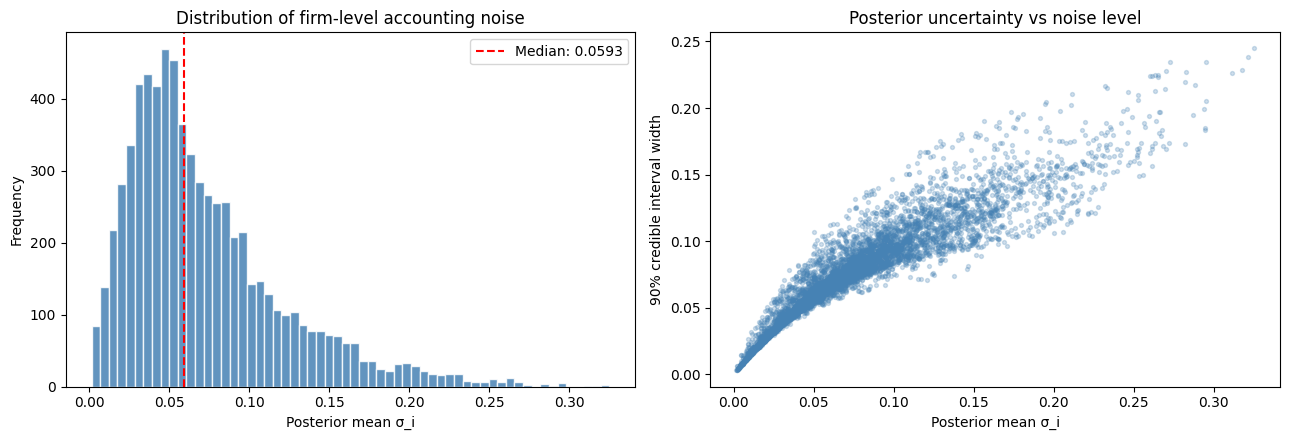

In [10]:
# ────────────────────────────────────────────────────────────
# 1. Distribution of posterior mean σ_i + posterior uncertainty
# ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(sigma_summary["sigma_mean"], bins=60,
             edgecolor="white", alpha=0.85, color="steelblue")
axes[0].axvline(sigma_summary["sigma_mean"].median(), color="red", ls="--",
                label=f"Median: {sigma_summary['sigma_mean'].median():.4f}")
axes[0].set_xlabel("Posterior mean σ_i")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of firm-level accounting noise")
axes[0].legend()

# 90% CI width vs posterior mean — do noisier firms have more uncertain σ_i?
sigma_summary["ci_width"] = sigma_summary["sigma_q95"] - sigma_summary["sigma_q05"]
axes[1].scatter(sigma_summary["sigma_mean"], sigma_summary["ci_width"],
                alpha=0.25, s=8, color="steelblue")
axes[1].set_xlabel("Posterior mean σ_i")
axes[1].set_ylabel("90% credible interval width")
axes[1].set_title("Posterior uncertainty vs noise level")

plt.tight_layout()
plt.savefig(PLOT_DIR / "sigma_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/y_/vpxp1t197mzf59bbg2x2qgt80000gn/T/ipykernel_33272/1034392019.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=sector_order, showfliers=False, patch_artist=True)


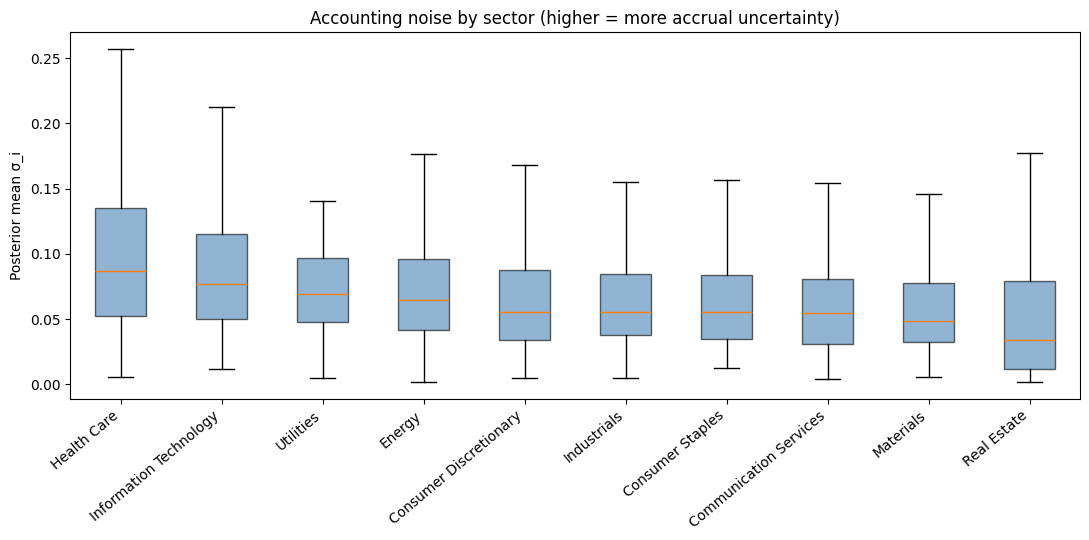

In [11]:
# ────────────────────────────────────────────────────────────
# 2. σ_i by sector (box plot, outliers hidden)
# ────────────────────────────────────────────────────────────
sector_order = (
    sigma_with_sector.groupby("Sector")["sigma_mean"].median()
    .sort_values(ascending=False).index.tolist()
)

fig, ax = plt.subplots(figsize=(11, 5.5))
box_data = [sigma_with_sector.loc[sigma_with_sector["Sector"] == s, "sigma_mean"]
            for s in sector_order]
bp = ax.boxplot(box_data, labels=sector_order, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)

ax.set_ylabel("Posterior mean σ_i")
ax.set_title("Accounting noise by sector (higher = more accrual uncertainty)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(PLOT_DIR / "sigma_by_sector.png", dpi=150, bbox_inches="tight")
plt.show()

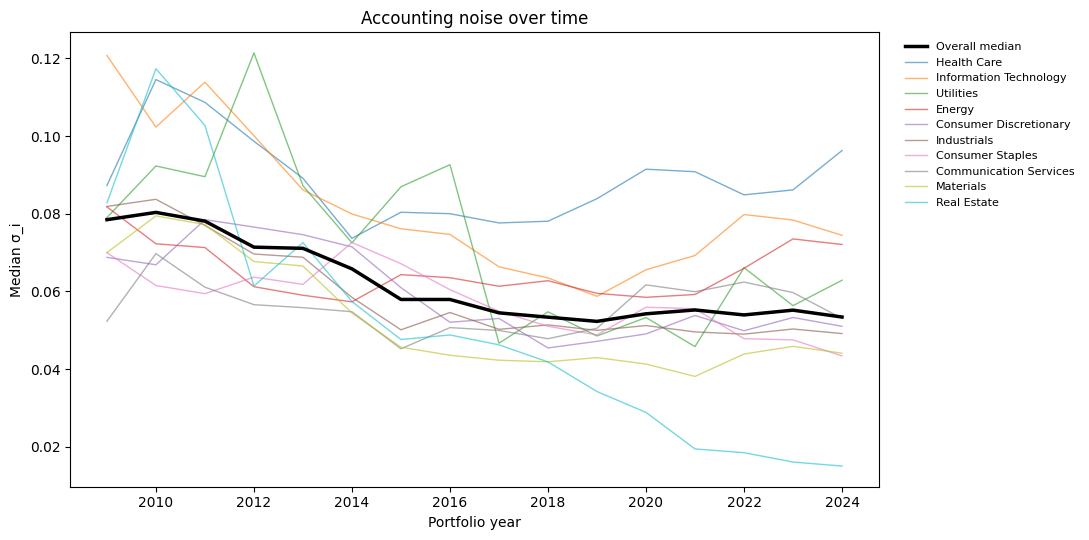

In [12]:
# ────────────────────────────────────────────────────────────
# 3. Time series of median σ_i per year (by sector)
# ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))

# Overall median line
overall_median = sigma_summary.groupby("Year")["sigma_mean"].median()
ax.plot(overall_median.index, overall_median.values, color="black",
        lw=2.5, label="Overall median", zorder=10)

# One faint line per sector
for sector in sector_order:
    yearly = (sigma_with_sector.loc[sigma_with_sector["Sector"] == sector]
              .groupby("Year")["sigma_mean"].median())
    ax.plot(yearly.index, yearly.values, alpha=0.6, lw=1, label=sector)

ax.set_xlabel("Portfolio year")
ax.set_ylabel("Median σ_i")
ax.set_title("Accounting noise over time")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(PLOT_DIR / "sigma_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

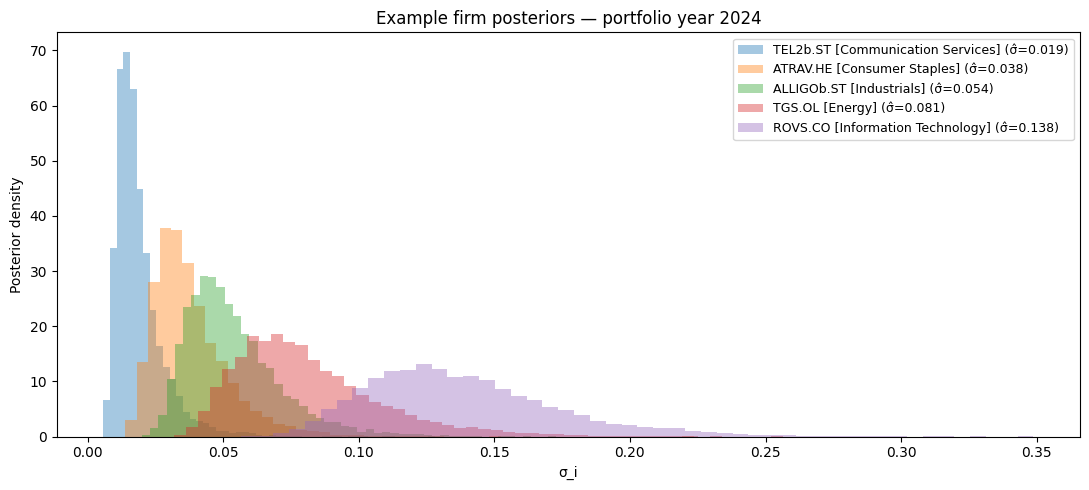


All diagnostic plots saved to ../data/hb_results/baseline/plots


In [13]:
# ────────────────────────────────────────────────────────────
# 4. Example posteriors — 5 firms at different noise percentiles
# ────────────────────────────────────────────────────────────
latest_year = max(all_results.keys())
latest_results = all_results[latest_year]

# Pick 5 firms spanning the σ distribution at the latest year
latest_sigma_means = {k: np.mean(v) for k, v in latest_results.items()}
sorted_firms = sorted(latest_sigma_means.items(), key=lambda x: x[1])
n = len(sorted_firms)

if n >= 10:
    example_firms = [sorted_firms[int(n * p)][0] for p in [0.1, 0.3, 0.5, 0.7, 0.9]]

    fig, ax = plt.subplots(figsize=(11, 5))
    for firm_idx in example_firms:
        draws = latest_results[firm_idx]
        ticker = firm_map_rev.get(firm_idx, f"firm_{firm_idx}")
        sector = sector_info.loc[sector_info["Ticker"] == ticker, "Sector"].values
        sector_label = sector[0] if len(sector) else "?"
        ax.hist(draws, bins=50, alpha=0.4, density=True,
                label=f"{ticker} [{sector_label}] (σ̂={np.mean(draws):.3f})")

    ax.set_xlabel("σ_i")
    ax.set_ylabel("Posterior density")
    ax.set_title(f"Example firm posteriors — portfolio year {latest_year}")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "sigma_posterior_examples.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Skipping example-firm plot: only {n} firms in {latest_year} (need ≥10).")

print(f"\nAll diagnostic plots saved to {PLOT_DIR}")